In [1]:
!kaggle datasets download prasad22/healthcare-dataset

Dataset URL: https://www.kaggle.com/datasets/prasad22/healthcare-dataset
License(s): CC0-1.0
100% 2.91M/2.91M [00:00<00:00, 257MB/s]



In [2]:
!unzip healthcare-dataset.zip
!ls

Archive:  healthcare-dataset.zip
  inflating: healthcare_dataset.csv  
healthcare_dataset.csv	healthcare-dataset.zip	sample_data


In [4]:
!pip -q install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 5.7 MB/s eta 0:00:00


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    classification_report
)

from sklearn.decomposition import PCA

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
import category_encoders as ce

from sklearn.inspection import permutation_importance

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [6]:
df = pd.read_csv("healthcare_dataset.csv")
df.head(2)

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  object 
 12  Discharge Date      55500 non-null  object 
 13  Medication          55500 non-null  object 
 14  Test Results        55500 non-null  object 
dtypes: float64(1), int64(2), object(12)
memory usage: 6.4

In [8]:
df.describe(include="all")

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
count,55500,55500.000000,55500,55500,55500,55500,55500,55500,55500,55500.000000,55500.000000,55500,55500,55500,55500
unique,49992,NaN,2,8,6,1827,40341,39876,5,NaN,NaN,3,1856,5,3
top,DAvId muNoZ,NaN,Male,A-,Arthritis,2024-03-16,Michael Smith,LLC Smith,Cigna,NaN,NaN,Elective,2020-03-15,Lipitor,Abnormal
freq,3,NaN,27774,6969,9308,50,27,44,11249,NaN,NaN,18655,53,11140,18627
mean,NaN,51.539459,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25539.316097,301.134829,NaN,NaN,NaN,NaN
std,NaN,19.602454,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14211.454431,115.243069,NaN,NaN,NaN,NaN
min,NaN,13.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-2008.492140,101.000000,NaN,NaN,NaN,NaN
25%,NaN,35.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13241.224652,202.000000,NaN,NaN,NaN,NaN
50%,NaN,52.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25538.069376,302.000000,NaN,NaN,NaN,NaN
75%,NaN,68.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37820.508436,401.000000,NaN,NaN,NaN,NaN


In [9]:
df.shape

(55500, 15)

**EDA**

<Axes: xlabel='Test Results'>

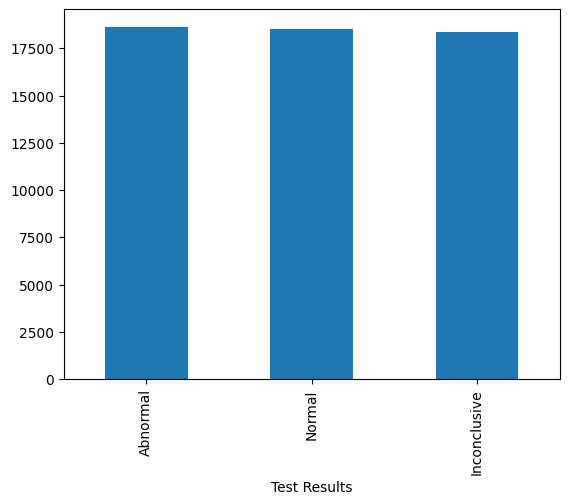

In [10]:
df["Test Results"].value_counts().plot(kind='bar')

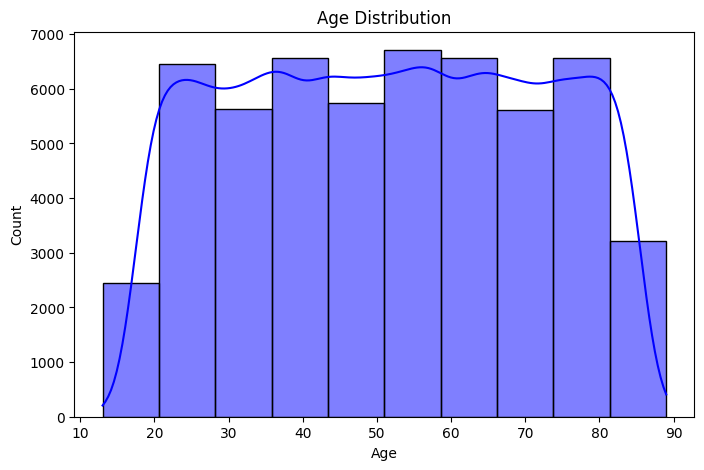

In [11]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Age", bins=10, kde=True, color="blue")
plt.title('Age Distribution')
plt.show()

/tmp/ipykernel_1807/2135121655.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Test Results', y='Billing Amount', palette='Set2')


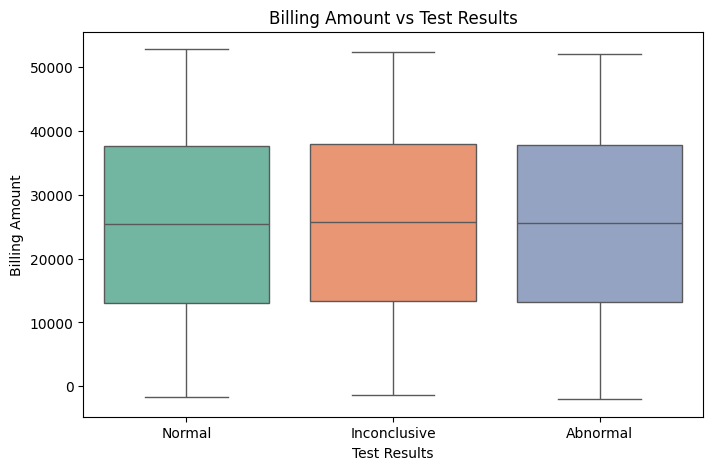

In [12]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Test Results', y='Billing Amount', palette='Set2')
plt.title('Billing Amount vs Test Results')
plt.show()

**Data Preprocessing**

In [13]:
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'])
df['Discharge Date'] = pd.to_datetime(df['Discharge Date'])
df['Length_of_Stay_Days'] = (df['Discharge Date'] - df['Date of Admission']).dt.days

cols_drop = ['Name', 'Room Number', 'Date of Admission', 'Discharge Date']
df = df.drop(columns=cols_drop)

In [14]:
x = df.drop(columns=["Test Results"])
y = df['Test Results']

In [15]:
le = LabelEncoder()
y = le.fit_transform(y)

In [16]:
admission_mapping = {'Elective': 0, 'Urgent': 1, 'Emergency': 2}
x['Admission Type'] = x['Admission Type'].map(admission_mapping)

In [17]:
x = pd.get_dummies(x, columns=['Gender', 'Blood Type', 'Medical Condition'], drop_first=True, dtype=int)

In [18]:
high_card_cols = ['Doctor', 'Hospital', 'Insurance Provider', 'Medication']

target_encoder = ce.TargetEncoder(cols=high_card_cols)
x[high_card_cols] = target_encoder.fit_transform(x[high_card_cols], y)

In [19]:
final_df = pd.concat([pd.DataFrame(x), pd.Series(y, name='Target')], axis=1)

print(final_df.shape)
final_df.head(2)

(55500, 22)


,Age,Doctor,Hospital,Insurance Provider,Billing Amount,Admission Type,Medication,Length_of_Stay_Days,Gender_Male,Blood Type_A-,...,Blood Type_B+,Blood Type_B-,Blood Type_O+,Blood Type_O-,Medical Condition_Asthma,Medical Condition_Cancer,Medical Condition_Diabetes,Medical Condition_Hypertension,Medical Condition_Obesity,Target
0,30,1.199124,0.998442,1.004612,18856.281306,1,0.992413,2,1,0,...,0,1,0,0,0,1,0,0,0,2
1,62,0.998276,0.932471,0.994083,33643.327287,2,0.998922,6,1,0,...,0,0,0,0,0,0,0,0,1,1


**Split Data**

In [20]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.20,
    random_state=42
)

print("Train:", x_train.shape, "Test:", x_test.shape)

Train: (44400, 21) Test: (11100, 21)


**Scaler and PCA**

In [21]:
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [22]:
pca = PCA(n_components=0.95, random_state=42)

x_train_pca = pca.fit_transform(x_train_scaled)
x_test_pca = pca.fit_transform(x_test_scaled)

In [23]:
print(pca.explained_variance_ratio_)

[0.08667542 0.05941845 0.05792994 0.05736501 0.05681532 0.05561714
 0.05507587 0.05484978 0.0542814  0.05375347 0.05177381 0.04845245
 0.04815236 0.04770879 0.0474906  0.046403   0.04582057 0.04567481]


### Evaluation utilities

In [24]:
def evaluate_binary_classifier(name, y_true, y_pred, y_proba=None):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="weighted")
    rec = recall_score(y_true, y_pred, average="weighted")
    f1 = f1_score(y_true, y_pred, average="weighted")
    output = {"model": name, "accuracy": acc, "precision": prec, "recall": rec, "f1": f1}
    
    if y_proba is not None:
        try:
            auc = roc_auc_score(y_true, y_proba, multi_class='ovr')
            output["roc_auc"] = auc
        except ValueError:
            output["roc_auc"] = None
    
    print(f"\n=== {name} ===")
    print({k: round(v, 4) for k, v in output.items() if k != "model" and v is not None})
    print("\nClassification report:")
    print(classification_report(y_true, y_pred, digits=4, zero_division=0))
    
    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot()
    plt.title(f"Confusion Matrix — {name}")
    plt.show()

    return output

### Train Multiple Models

In [25]:
models = {
    "LogReg": LogisticRegression(max_iter=3000, random_state=RANDOM_STATE),
    "DecisionTree": DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE),
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
    "KNN": KNeighborsClassifier(n_neighbors=15),
    "XGB" : XGBClassifier(random_state=RANDOM_STATE)
}

Training LogReg Model

=== LogReg ===
{'accuracy': 0.9214, 'precision': 0.9232, 'recall': 0.9214, 'f1': 0.9219}

Classification report:
              precision    recall  f1-score   support

           0     0.9537    0.9275    0.9404      3754
           1     0.8595    0.9118    0.8849      3617
           2     0.9543    0.9244    0.9391      3729

    accuracy                         0.9214     11100
   macro avg     0.9225    0.9212    0.9215     11100
weighted avg     0.9232    0.9214    0.9219     11100



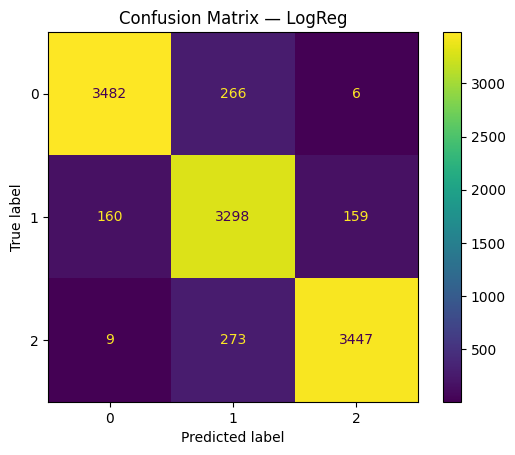

Training DecisionTree Model

=== DecisionTree ===
{'accuracy': 0.9026, 'precision': 0.9059, 'recall': 0.9026, 'f1': 0.9035}

Classification report:
              precision    recall  f1-score   support

           0     0.9283    0.9206    0.9244      3754
           1     0.8274    0.8919    0.8584      3617
           2     0.9595    0.8949    0.9260      3729

    accuracy                         0.9026     11100
   macro avg     0.9050    0.9025    0.9030     11100
weighted avg     0.9059    0.9026    0.9035     11100



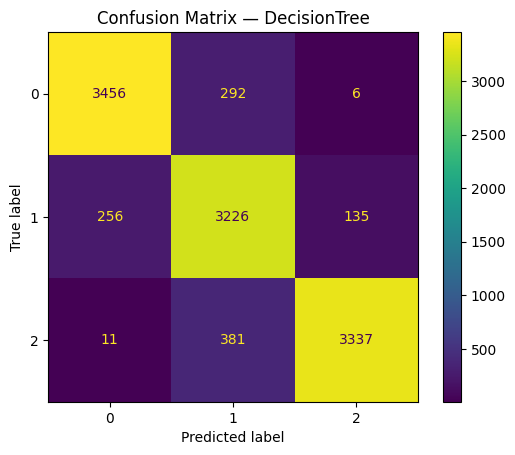

Training RandomForest Model

=== RandomForest ===
{'accuracy': 0.9159, 'precision': 0.9177, 'recall': 0.9159, 'f1': 0.9165}

Classification report:
              precision    recall  f1-score   support

           0     0.9522    0.9227    0.9372      3754
           1     0.8532    0.9016    0.8767      3617
           2     0.9456    0.9230    0.9342      3729

    accuracy                         0.9159     11100
   macro avg     0.9170    0.9158    0.9160     11100
weighted avg     0.9177    0.9159    0.9165     11100



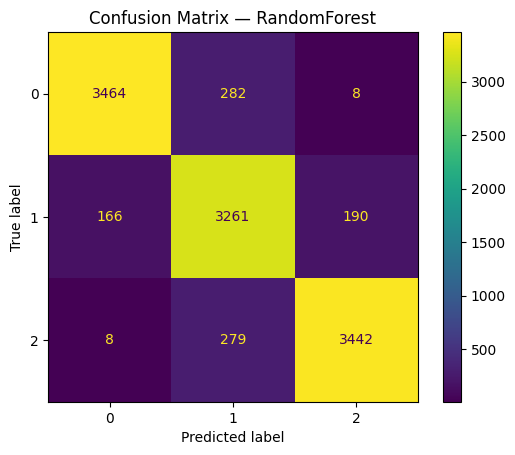

Training KNN Model

=== KNN ===
{'accuracy': 0.8945, 'precision': 0.9035, 'recall': 0.8945, 'f1': 0.8963}

Classification report:
              precision    recall  f1-score   support

           0     0.9585    0.8855    0.9205      3754
           1     0.7915    0.9234    0.8524      3617
           2     0.9569    0.8756    0.9144      3729

    accuracy                         0.8945     11100
   macro avg     0.9023    0.8948    0.8958     11100
weighted avg     0.9035    0.8945    0.8963     11100



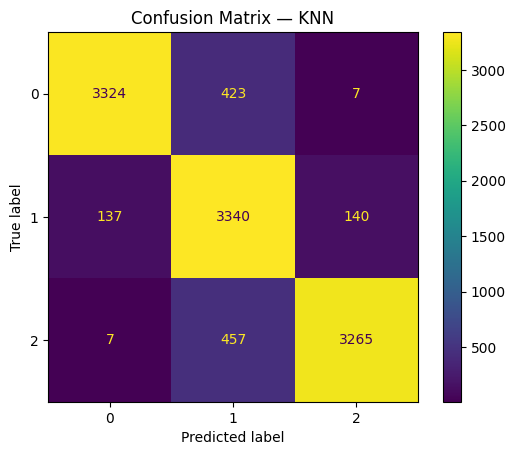

Training XGB Model

=== XGB ===
{'accuracy': 0.9031, 'precision': 0.9052, 'recall': 0.9031, 'f1': 0.9037}

Classification report:
              precision    recall  f1-score   support

           0     0.9455    0.9105    0.9277      3754
           1     0.8339    0.8844    0.8584      3617
           2     0.9337    0.9136    0.9236      3729

    accuracy                         0.9031     11100
   macro avg     0.9044    0.9029    0.9032     11100
weighted avg     0.9052    0.9031    0.9037     11100



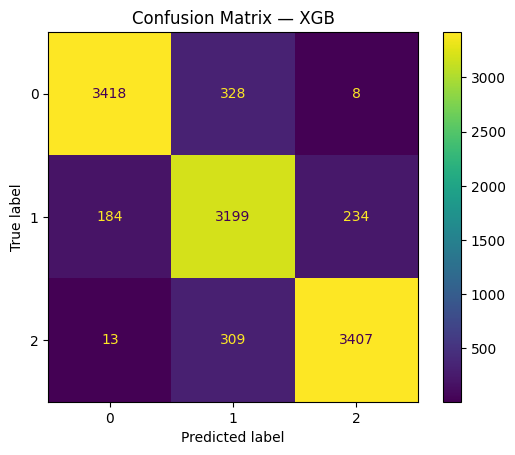

In [26]:
results = []

for name, model in models.items():
    print(f"Training {name} Model")
    
    model.fit(x_train_pca, y_train)
    
    y_pred = model.predict(x_test_pca)
    y_pred_proba = model.predict_proba(x_test_pca)[:, 1] if hasattr(model, 'predict_proba') else None
    
    results.append(evaluate_binary_classifier(name, y_test, y_pred, y_pred_proba))

In [27]:
results_df = pd.DataFrame(results).sort_values(by="accuracy", ascending=False)
display(results_df)

,model,accuracy,precision,recall,f1,roc_auc
0,LogReg,0.921351,0.923224,0.921351,0.921895,None
2,RandomForest,0.915946,0.917721,0.915946,0.916492,None
4,XGB,0.903063,0.905179,0.903063,0.903731,None
1,DecisionTree,0.902613,0.905881,0.902613,0.903469,None
3,KNN,0.894505,0.903533,0.894505,0.896269,None


In [29]:
cv_results = {}

for name, model in models.items():
    scores = cross_val_score(model, x_train_pca, y_train, scoring="accuracy", cv=5, n_jobs=-1)
    
    cv_results[name] = {
        'mean' : scores.mean(),
        'std' : scores.std()
    }
    print(f"{name:20s}: {scores.mean():.3f} (+/- {scores.std():.3f})")

LogReg              : 0.923 (+/- 0.002)
DecisionTree        : 0.926 (+/- 0.002)
RandomForest        : 0.930 (+/- 0.003)
KNN                 : 0.879 (+/- 0.002)
XGB                 : 0.928 (+/- 0.002)
